## Part 1: introduction

Data import:

In [1]:
import pandas as pd

df = pd.read_csv("data/SPX_data_26.02.24.csv")

df.head()

,underlying_symbol,quote_datetime,root,expiration,strike,option_type,open,high,low,close,trade_volume,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,open_interest,time_to_maturity
0,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,200.0,C,0.0,0.0,0.0,0.0,0,2,6673.0,1,6692.9,6852.66,6913.22,35,0.063014
1,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,400.0,C,0.0,0.0,0.0,0.0,0,1,6473.3,1,6492.5,6852.66,6913.22,13,0.063014
2,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,600.0,C,0.0,0.0,0.0,0.0,0,1,6273.5,1,6294.5,6852.66,6913.22,6,0.063014
3,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,800.0,C,0.0,0.0,0.0,0.0,0,2,6074.7,1,6093.2,6852.66,6913.22,9,0.063014
4,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,1000.0,C,0.0,0.0,0.0,0.0,0,10,5877.8,10,5892.1,6852.66,6913.22,1101,0.063014


In [3]:
from src.black_scholes import implied_volatility

df['C_mkt'] = (df['bid'] + df['ask']) / 2
df['S_0'] = (df['underlying_bid'] + df['underlying_ask']) / 2
r_annual = 0.045 

# compute IV for the whole dataset
df['implied_vol'] = df.apply(
    lambda row: implied_volatility(row['C_mkt'], row['S_0'], row['strike'], row['time_to_maturity'], r_annual),
    axis=1
)

# clean the dataset
df_clean = df.dropna(subset=['implied_vol'])

In [4]:
df_clean.to_csv('data/SPX_data_clean_IV.csv', index=False)

Volatility smile:

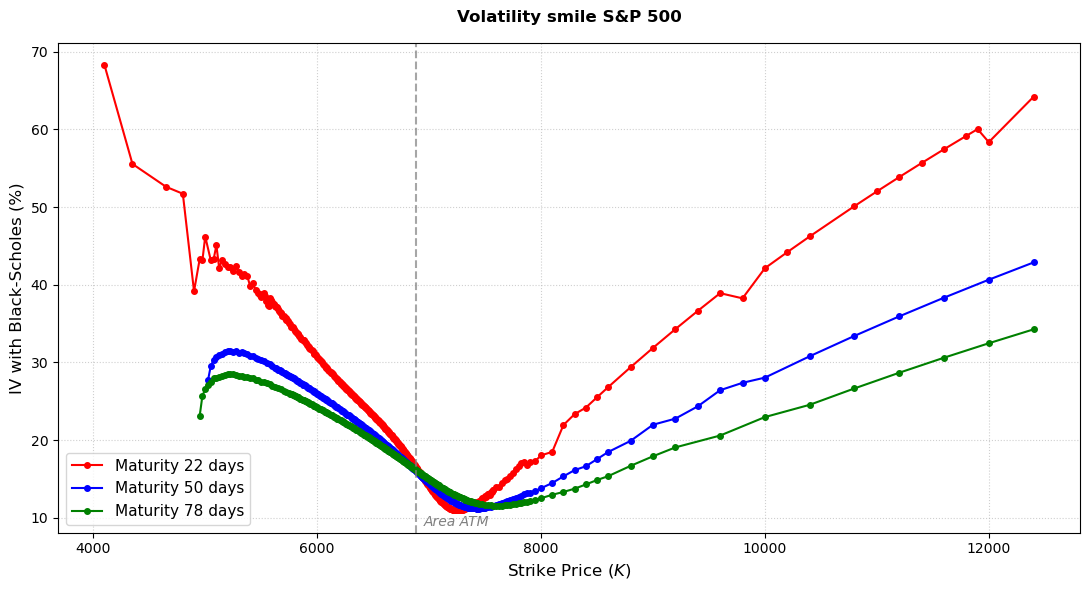

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_market = pd.read_csv('data/SPX_data_clean_IV.csv')

# select top 3 most common maturities
top_maturities = df_market['time_to_maturity'].value_counts().head(3).index.tolist()

plt.figure(figsize=(11, 6))
colori = ['red', 'blue', 'green']

for i, t in enumerate(sorted(top_maturities)):
    # keep only data with the selected maturity
    df_maturity = df_market[df_market['time_to_maturity'] == t].sort_values(by='strike')
    plt.plot(df_maturity['strike'], df_maturity['implied_vol'] * 100, 
             marker='o', linestyle='-', color=colori[i], markersize=4,
             label=f"Maturity {int(t*365)} days")

# Personalizzazione del grafico
plt.title("Volatility smile S&P 500", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Strike Price ($K$)", fontsize=12)
plt.ylabel("IV with Black-Scholes (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Evidenziamo graficamente il prezzo Spot medio sul grafico per dare contesto (ATM)
S0_medio = (df_market['underlying_bid'] + df_market['underlying_ask']).mean() / 2
plt.axvline(x=S0_medio, color='gray', linestyle='--', alpha=0.7, label=f'Spot S0 (~{S0_medio:.1f})')
plt.text(S0_medio * 1.01, plt.ylim()[0] * 1.1, 'Area ATM', color='gray', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

## Part 2: synthetic dataset creation

In [2]:
import os
import numpy as np
import pandas as pd
import src.heston as hst
from src.black_scholes import implied_volatility
from tqdm import tqdm  

# reading dataset with IV and extract ranges for parameters
df_market = pd.read_csv('data/SPX_data_clean_IV.csv')
df_market['S0_mid'] = (df_market['underlying_bid'] + df_market['underlying_ask']) / 2
S0_mercato = df_market['S0_mid'].mean()

T_min, T_max = df_market['time_to_maturity'].min(), df_market['time_to_maturity'].max()
df_market['moneyness_real'] = df_market['strike'] / df_market['S0_mid']
moneyness_min, moneyness_max = df_market['moneyness_real'].min(), df_market['moneyness_real'].max()

df_atm = df_market[(df_market['moneyness_real'] >= 0.98) & (df_market['moneyness_real'] <= 1.02)]
variance_min = max(0.005, df_atm['implied_vol'].min() ** 2)
variance_max = min(0.25, df_atm['implied_vol'].max() ** 2)


In [ ]:

# generate synthetic dataset
N_SAMPLES = 20000
dataset_rows = []

print(f"Synthetic data generation:")
for i in tqdm(range(N_SAMPLES), desc="Progress:"):
    kappa_casuale = np.random.uniform(0.1, 5.0)
    xi_casuale = np.random.uniform(0.05, 1.0)
    rho_casuale = np.random.uniform(-0.95, 0.0)  
    theta_casuale = np.random.uniform(variance_min, variance_max)
    V0_casuale = np.random.uniform(variance_min, variance_max)
    
    maturity_casuale = np.random.uniform(T_min, T_max)
    moneyness_casuale = np.random.uniform(moneyness_min, moneyness_max)
    strike_casuale = S0_mercato * moneyness_casuale
    
    try:
        # calculate Heston price
        price_heston = hst.heston_call_price(
            S0=S0_mercato, K=strike_casuale, T=maturity_casuale, r=r_annual,
            kappa=kappa_casuale, theta=theta_casuale, xi=xi_casuale, rho=rho_casuale, V0=V0_casuale
        )
        
        # convert Heston price to implied volatility
        target_iv = implied_volatility(price_heston, S0_mercato, strike_casuale, maturity_casuale, r_annual)
        
        if not np.isnan(target_iv) and target_iv > 0:
            dataset_rows.append([kappa_casuale, theta_casuale, xi_casuale, rho_casuale, V0_casuale, strike_casuale, maturity_casuale, target_iv])
    except:
        continue

# save new dataset
columns = ['kappa', 'theta', 'xi', 'rho', 'V0', 'strike', 'time_to_maturity', 'target_iv']
df_sintetico = pd.DataFrame(dataset_rows, columns=columns)
os.makedirs('data', exist_ok=True)
df_sintetico.to_csv('data/heston_synthetic_dataset.csv', index=False)

print(f"Samples generated: {len(df_sintetico)}.")

## Part 3: define and train NN

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  

import torch
import joblib
import src.nn_for_volatility as hst_nn

# Definiamo i percorsi dove sono salvati i pesi e lo scaler
PATH_MODELLO = 'models/heston_pytorch_model.pth'
PATH_SCALER = 'models/heston_pytorch_scaler.pkl'


if os.path.exists(PATH_MODELLO) and os.path.exists(PATH_SCALER):
    print("Uploading model:")
    
    model = hst_nn.heston_volatility_nn()
    model.load_state_dict(torch.load(PATH_MODELLO))
    model.eval()
    scaler = joblib.load(PATH_SCALER)
    
    print("Model uploaded.")

else:
    print("Model not found: training in progress.")
    
    # if the files don't exist, train the model and save it
    model, scaler = hst_nn.train_heston_model(
        csv_path='data/heston_synthetic_dataset.csv',
        epochs=120,
        batch_size=32,
        patience=12
    )
    print("Model trained and saved.")

Model not found: training in progress.
Start training.
Epoch 1/120 | Train Loss: 0.015653 | Val Loss: 0.008684
Epoch 5/120 | Train Loss: 0.003946 | Val Loss: 0.003375
Epoch 10/120 | Train Loss: 0.002125 | Val Loss: 0.002193
Epoch 15/120 | Train Loss: 0.001514 | Val Loss: 0.001812
Epoch 20/120 | Train Loss: 0.001292 | Val Loss: 0.001653
Epoch 25/120 | Train Loss: 0.001063 | Val Loss: 0.001299
Epoch 30/120 | Train Loss: 0.000921 | Val Loss: 0.001242
Epoch 35/120 | Train Loss: 0.000837 | Val Loss: 0.001006
Epoch 40/120 | Train Loss: 0.000757 | Val Loss: 0.001048
Epoch 45/120 | Train Loss: 0.000780 | Val Loss: 0.000945
Epoch 50/120 | Train Loss: 0.000643 | Val Loss: 0.000983
Epoch 55/120 | Train Loss: 0.000603 | Val Loss: 0.001166
Epoch 60/120 | Train Loss: 0.000587 | Val Loss: 0.000884
Epoch 65/120 | Train Loss: 0.000499 | Val Loss: 0.000813
Epoch 70/120 | Train Loss: 0.000462 | Val Loss: 0.000804
Epoch 75/120 | Train Loss: 0.000396 | Val Loss: 0.000759
Epoch 80/120 | Train Loss: 0.000419

## Part 4: calibration

In [7]:
from scipy.optimize import minimize
import numpy as np

df_market = pd.read_csv('data/SPX_data_clean_IV.csv')

# Bounds equilibrati: lasciamo scendere la varianza ma teniamo xi sotto controllo
bounds = [
    (0.5, 3.0),    # kappa
    (0.002, 0.035), # theta: abbassato il tetto da 0.06 a 0.035 (schiaccia la risalita a lungo termine)
    (0.05, 0.30),  # xi: ridotto a 0.30 per eliminare ogni accenno di instabilità/ondulazione
    (-0.85, -0.3), # rho
    (0.002, 0.035)  # V0: allineato a theta
]

initial_guess = [1.2, 0.01, 0.15, -0.6, 0.01]

result = minimize(
    fun=hst_nn.heston_pytorch_objective,
    x0=initial_guess,
    args=(df_market, model, scaler), # <--- Calibriamo sull'INTERO dataset di mercato!
    method='L-BFGS-B',
    bounds=bounds,
    options={'disp': True, 'maxiter': 150, 'ftol': 1e-8}
)

kappa_opt, theta_opt, xi_opt, rho_opt, V0_opt = result.x

C:\Users\camil\AppData\Local\Temp\ipykernel_22096\635394797.py:17: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



In [8]:
import numpy as np
import pandas as pd
import torch
import plotly.graph_objects as go

print("--- GENERAZIONE SUPERFICIE 3D INTERATTIVA (PLOTLY) ---")

# 1. Carichiamo i dati reali e calcoliamo Moneyness e Spot
df_market = pd.read_csv('data/SPX_data_clean_IV.csv')
df_market['S0_mid'] = (df_market['underlying_bid'] + df_market['underlying_ask']) / 2
S0_mercato = df_market['S0_mid'].mean()
df_market['moneyness'] = df_market['strike'] / df_market['S0_mid']

# Dati di mercato per lo scatter plot 3D
X_mkt = df_market['moneyness'].values
Y_mkt = df_market['time_to_maturity'].values
Z_mkt = df_market['implied_vol'].values * 100  # In %

# 2. Creiamo la griglia regolare (Meshgrid) per la superficie della Rete Neurale
moneyness_grid = np.linspace(X_mkt.min(), X_mkt.max(), 50)
ttm_grid = np.linspace(Y_mkt.min(), Y_mkt.max(), 50)
X_mesh, Y_mesh = np.meshgrid(moneyness_grid, ttm_grid)

# 3. Prepariamo gli input per il Surrogate Model
n_grid_points = X_mesh.size
inputs_grid = np.zeros((n_grid_points, 7), dtype=np.float32)

# Parametri ottimali calibrati (fissi)
inputs_grid[:, 0] = kappa_opt
inputs_grid[:, 1] = theta_opt
inputs_grid[:, 2] = xi_opt
inputs_grid[:, 3] = rho_opt
inputs_grid[:, 4] = V0_opt
inputs_grid[:, 5] = X_mesh.flatten() * S0_mercato  # Convertiamo moneyness in strike ($K$)
inputs_grid[:, 6] = Y_mesh.flatten()

# 4. Predizione con PyTorch
inputs_grid_scaled = scaler.transform(inputs_grid).astype(np.float32)
inputs_grid_t = torch.tensor(inputs_grid_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions_grid = model(inputs_grid_t).numpy().flatten() * 100  # In %

Z_mesh = predictions_grid.reshape(X_mesh.shape)

# ==============================================================================
# 5. COSTRUZIONE DEL GRAFICO 3D INTERATTIVO CON PLOTLY
# ==============================================================================

fig = go.Figure()

# A. Aggiungiamo la superficie continua della Rete Neurale
fig.add_trace(go.Surface(
    x=moneyness_grid,
    y=ttm_grid,
    z=Z_mesh,
    colorscale='Viridis',
    opacity=0.7,
    name='Heston AI Surface',
    colorbar=dict(title="IV (%)", x=1.05)
))

# B. Aggiungiamo i punti reali di mercato dello S&P 500
fig.add_trace(go.Scatter3d(
    x=X_mkt,
    y=Y_mkt,
    z=Z_mkt,
    mode='markers',
    marker=dict(
        size=3,
        color='black',
        opacity=0.6
    ),
    name='Dati Reali S&P 500'
))

# Personalizzazione del layout, dei titoli e degli assi
fig.update_layout(
    title=dict(
        text="Superficie Interattiva di Volatilità: Heston AI vs Mercato SPX",
        x=0.5,
        font=dict(size=16, family="Arial", color="black")
    ),
    scene=dict(
        xaxis_title="Moneyness (K/S0)",
        yaxis_title="Time to Maturity (Anni)",
        zaxis_title="Volatilità Implicita (%)",
        camera=dict(
            eye=dict(x=-1.5, y=-1.5, z=1.2) # Angolazione iniziale della camera
        )
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(x=0.01, y=0.99),
    width=950,
    height=650
)

# Mostra il grafico nel notebook
fig.show()

--- GENERAZIONE SUPERFICIE 3D INTERATTIVA (PLOTLY) ---


In [7]:
import pandas as pd
print(pd.read_csv('data/heston_synthetic_dataset.csv')['target_iv'].head())

0    0.262530
1    0.466723
2    0.494704
3    0.262228
4    0.281841
Name: target_iv, dtype: float64
